USING GROUP BY

ANSWER 2 QUESTIONS:


1.   Find the Max Temperature in each city
2.   Find avg wind speed per city



In [ ]:
import pandas as pd
df = pd.read_csv("weather_by_cities.csv")
df

,day,city,temperature,windspeed,event
0,1/1/2017,new york,32,6,Rain
1,1/2/2017,new york,36,7,Sunny
2,1/3/2017,new york,28,12,Snow
3,1/4/2017,new york,33,7,Sunny
4,1/1/2017,mumbai,90,5,Sunny
5,1/2/2017,mumbai,85,12,Fog
6,1/3/2017,mumbai,87,15,Fog
7,1/4/2017,mumbai,92,5,Rain
8,1/1/2017,paris,45,20,Sunny
9,1/2/2017,paris,50,13,Cloudy


GROUPING THE DATA BASE BY CITIES

In [ ]:
#We obtain an Object when using groupby
g = df.groupby("city")
g

LOOKING THE OBJECT 'g'

In [ ]:
#In g always is fisrt the key value ('city') and the the corresponding dataframe
for city, city_df in g:
  print(city)
  print(city_df)

mumbai
        day    city  temperature  windspeed  event
4  1/1/2017  mumbai           90          5  Sunny
5  1/2/2017  mumbai           85         12    Fog
6  1/3/2017  mumbai           87         15    Fog
7  1/4/2017  mumbai           92          5   Rain
new york
        day      city  temperature  windspeed  event
0  1/1/2017  new york           32          6   Rain
1  1/2/2017  new york           36          7  Sunny
2  1/3/2017  new york           28         12   Snow
3  1/4/2017  new york           33          7  Sunny
paris
         day   city  temperature  windspeed   event
8   1/1/2017  paris           45         20   Sunny
9   1/2/2017  paris           50         13  Cloudy
10  1/3/2017  paris           54          8  Cloudy
11  1/4/2017  paris           42         10  Cloudy


ACCESING SPECIFIC DATAFRAME

In [ ]:
g.get_group('paris')

,day,city,temperature,windspeed,event
8,1/1/2017,paris,45,20,Sunny
9,1/2/2017,paris,50,13,Cloudy
10,1/3/2017,paris,54,8,Cloudy
11,1/4/2017,paris,42,10,Cloudy


OBTAINING THE MAX TEMPERATURE AND WIND SPEED IN EACH CITY


In [ ]:
g.max()

,day,temperature,windspeed,event
city,,,,
mumbai,1/4/2017,92,15,Sunny
new york,1/4/2017,36,12,Sunny
paris,1/4/2017,54,20,Sunny


CALCULATING AVG WIND SPEED AND TEMPERATURE

In [ ]:
g.mean(numeric_only=True)

,temperature,windspeed
city,,
mumbai,88.50,9.25
new york,32.25,8.00
paris,47.75,12.75


In [ ]:
g['windspeed'].mean()

,windspeed
city,
mumbai,9.25
new york,8.00
paris,12.75


ALL BASIC STATISTICS

In [ ]:
g.describe()

temperature                                                   \
               count   mean       std   min    25%   50%    75%   max   
city                                                                    
mumbai           4.0  88.50  3.109126  85.0  86.50  88.5  90.50  92.0   
new york         4.0  32.25  3.304038  28.0  31.00  32.5  33.75  36.0   
paris            4.0  47.75  5.315073  42.0  44.25  47.5  51.00  54.0   

         windspeed                                                 
             count   mean       std  min   25%   50%    75%   max  
city                                                               
mumbai         4.0   9.25  5.057997  5.0  5.00   8.5  12.75  15.0  
new york       4.0   8.00  2.708013  6.0  6.75   7.0   8.25  12.0  
paris          4.0  12.75  5.251984  8.0  9.50  11.5  14.75  20.0

VISUALIZING THE TEMPERATURE AND WIDSPEED WITH MATPLOTLIB

,0
city,
mumbai,"Axes(0.125,0.11;0.775x0.77)"
new york,"Axes(0.125,0.11;0.775x0.77)"
paris,"Axes(0.125,0.11;0.775x0.77)"


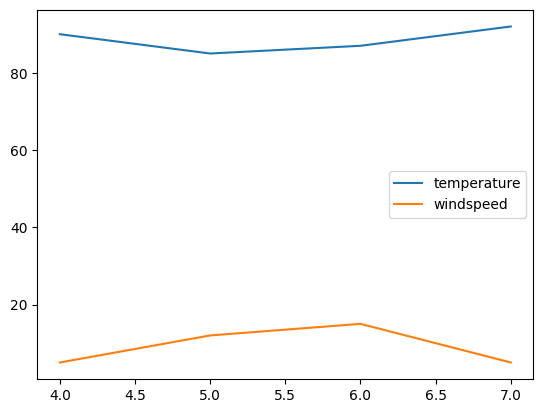

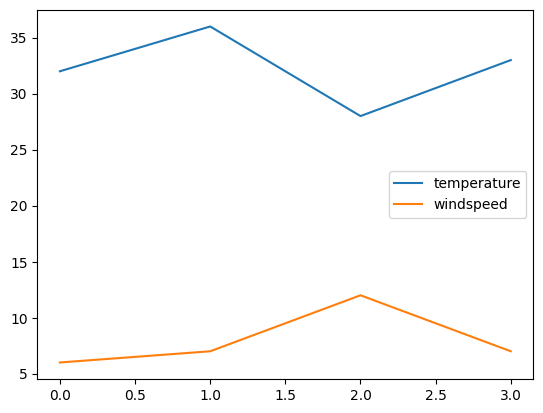

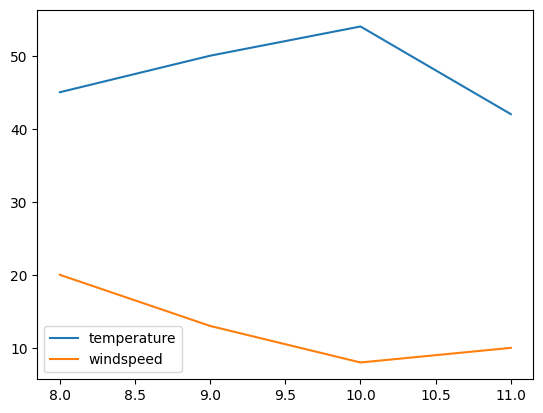

In [ ]:
%matplotlib inline
g.plot()

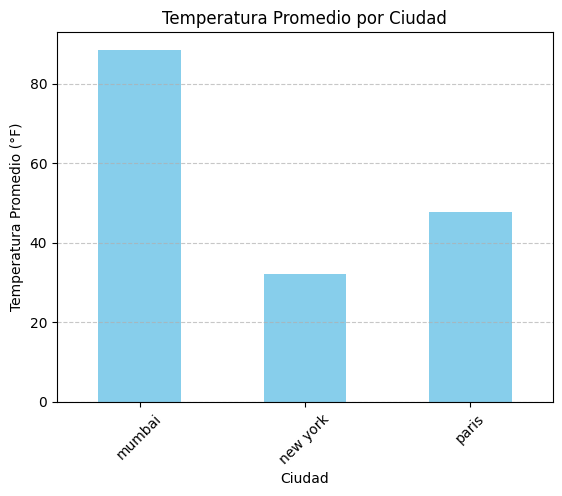

In [ ]:
import matplotlib.pyplot as plt

# Calcular la temperatura promedio por ciudad
avg_temp_per_city = g['temperature'].mean()

# Crear el gráfico de barras para la temperatura promedio
avg_temp_per_city.plot(kind='bar', color='skyblue')
plt.title('Temperatura Promedio por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Temperatura Promedio (°F)')
plt.xticks(rotation=45) #para no amontonar los nombres de ciudades
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

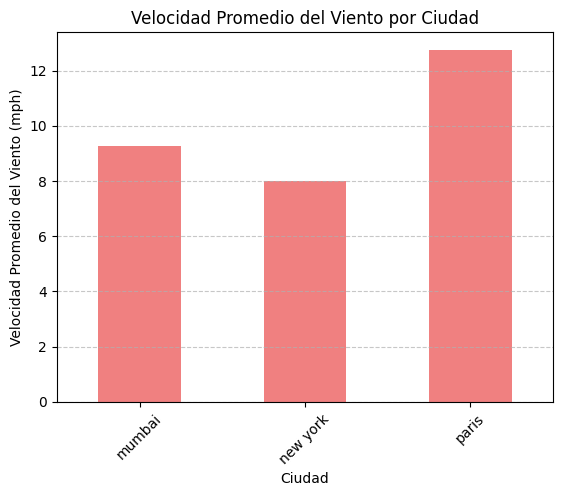

In [ ]:
# Calcular la velocidad promedio del viento por ciudad
avg_windspeed_per_city = g['windspeed'].mean()

# Crear el gráfico de barras para la velocidad promedio del viento
avg_windspeed_per_city.plot(kind='bar', color='lightcoral')
plt.title('Velocidad Promedio del Viento por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Velocidad Promedio del Viento (mph)')
plt.xticks(rotation=45) #para no amontonar los nombres de ciudades
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()